In [ ]:
# Load libraries and read the Titanic dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Display summary statistics for the dataset
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Show unique values in the Sex column
df['Sex'].unique()


array(['male', 'female'], dtype=object)

In [ ]:
# Check for missing values in each column
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Fill missing Age values with the median age
median = df['Age'].median()
df['Age'] = df['Age'].fillna(median)
# empty age cells filled with the median age


In [ ]:
# Drop the Cabin column because it has too many missing values
df = df.drop('Cabin', axis=1)


In [ ]:
# Fill missing Embarked values using the most common port
port = df['Embarked'].mode()[0]
print(port)
df['Embarked'] = df['Embarked'].fillna(port)


S


In [ ]:
# Confirm that all missing values are handled
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Encode categorical features for machine learning
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(df)


     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name  Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    0  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1   
2                               Heikkinen, Miss. Laina    1  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1   
4                             Allen, Mr. William Henry    0  35.0      0   
..                                                 ...  ...   ...    ...   
886        

In [ ]:
# Drop identifier and name columns
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)


In [ ]:
# Show first rows of cleaned data
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [ ]:
# Prepare features X and target label y
X = df.drop('Survived', axis=1)
y = df['Survived']
print(X)


     Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         3    0  22.0      1      0   7.2500         0
1         1    1  38.0      1      0  71.2833         1
2         3    1  26.0      0      0   7.9250         0
3         1    1  35.0      1      0  53.1000         0
4         3    0  35.0      0      0   8.0500         0
..      ...  ...   ...    ...    ...      ...       ...
886       2    0  27.0      0      0  13.0000         0
887       1    1  19.0      0      0  30.0000         0
888       3    1  28.0      1      2  23.4500         0
889       1    0  26.0      0      0  30.0000         1
890       3    0  32.0      0      0   7.7500         2

[891 rows x 7 columns]


In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Train initial Logistic Regression on raw data
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Make predictions on test set
y_pred = model.predict(X_test)


In [ ]:
# Calculate and display model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the model:")
print(f"{accuracy * 100:.2f}%")

Accuracy of the model:
79.89%


In [ ]:
# Print detailed classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
# Initialize the data scaler
scaler = StandardScaler()

In [ ]:
# Fit and transform training data; transform test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression on scaled features
model_scaled = LogisticRegression(random_state=42)
model_scaled.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
# Evaluate scaled Logistic Regression
y_pred_scaled = model_scaled.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred_scaled)
print(f"Accuracy on scaled data: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))


Accuracy on scaled data: 79.89%

Classification Report:


              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
# Train Random Forest on scaled features
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Evaluate Random Forest baseline model
y_pred_rf = rf_model.predict(X_test_scaled) 

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf) * 100)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 82.12290502793296

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [ ]:
# Engineer new feature: FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(df['FamilySize'])


0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 891, dtype: int64


In [ ]:
# Re-prepare features and target after feature engineering
X = df.drop('Survived', axis=1)
y = df['Survived']


In [ ]:
# Re-split train/test with new feature set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Re-scale features after adding FamilySize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Train Decision Tree baseline model
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_scaled, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Evaluate Decision Tree baseline model
tree_predictions = tree_model.predict(X_test_scaled)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_predictions) * 100)
print("\nClassification Report:\n", classification_report(y_test, tree_predictions))


Decision Tree Accuracy: 79.3296089385475

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       105
           1       0.74      0.77      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



Sex           26.842466
Fare          26.838622
Age           24.876480
Pclass         7.248017
FamilySize     4.836962
SibSp          3.679401
Embarked       3.183867
Parch          2.494185
dtype: float64


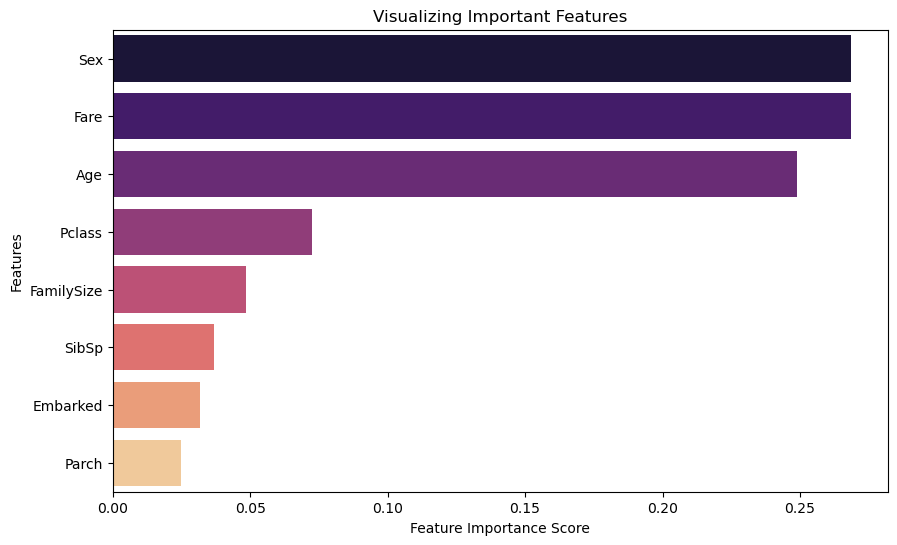

In [ ]:
# Compute and visualize feature importance from Random Forest
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# retrain the random forest using the current feature set
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

feature_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_imp * 100)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index, palette='magma', legend=False)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Visualizing Important Features')
plt.show()


In [31]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=0)
grid_search_rf.fit(X_train_scaled, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)

print(f"Random Forest - Best Accuracy: {accuracy_score(y_test, y_pred_best_rf)*100:.2f}%")

Random Forest - Best Accuracy: 82.68%


In [32]:
# Hyperparameter tuning for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search_lr = GridSearchCV(estimator=LogisticRegression(random_state=42, max_iter=1000), param_grid=param_grid_lr, cv=5, n_jobs=-1, verbose=0)
grid_search_lr.fit(X_train_scaled, y_train)

best_lr = grid_search_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_scaled)

print(f"Logistic Regression - Best Accuracy: {accuracy_score(y_test, y_pred_best_lr)*100:.2f}%")

Logistic Regression - Best Accuracy: 79.33%


In [33]:
# Hyperparameter tuning for Decision Tree
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid_dt, cv=5, n_jobs=-1, verbose=0)
grid_search_dt.fit(X_train_scaled, y_train)

best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_scaled)

print(f"Decision Tree - Best Accuracy: {accuracy_score(y_test, y_pred_best_dt)*100:.2f}%")

Decision Tree - Best Accuracy: 84.36%


In [34]:
# Show Best Parameters (Optional - فقط اگر لازم باشه)
print("Best Parameters Summary:")
print(f"Random Forest: {grid_search_rf.best_params_}")
print(f"Logistic Regression: {grid_search_lr.best_params_}")
print(f"Decision Tree: {grid_search_dt.best_params_}")

Best Parameters Summary:
Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


Random Forest: 82.68%
Logistic Regression: 79.33%
Decision Tree: 84.36%


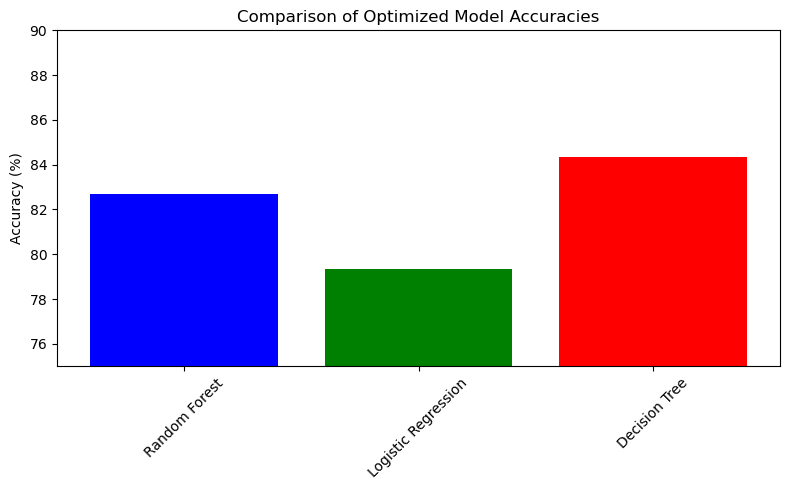

In [35]:
# Summary of Optimized Model Accuracies
models = ['Random Forest', 'Logistic Regression', 'Decision Tree']
accuracies = [
    accuracy_score(y_test, y_pred_best_rf) * 100,
    accuracy_score(y_test, y_pred_best_lr) * 100,
    accuracy_score(y_test, y_pred_best_dt) * 100
]

for model, acc in zip(models, accuracies):
    print(f"{model}: {acc:.2f}%")

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'red'])
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Optimized Model Accuracies')
plt.ylim(75, 90)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

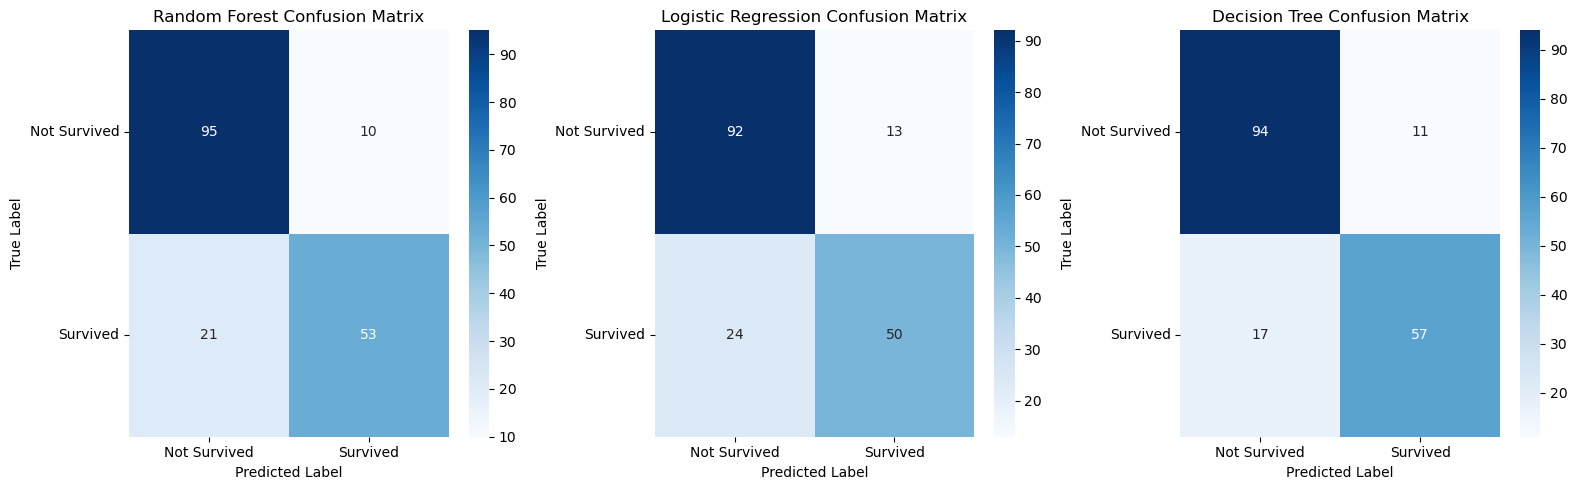

In [36]:
# Confusion matrices for the optimized models
from sklearn.metrics import confusion_matrix

# Use the existing predictions from each trained model
models = [best_rf, best_lr, best_dt]
predictions = [y_pred_best_rf, y_pred_best_lr, y_pred_best_dt]
titles = ['Random Forest', 'Logistic Regression', 'Decision Tree']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, preds, title in zip(axes, predictions, titles):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Not Survived', 'Survived'])
    ax.set_yticklabels(['Not Survived', 'Survived'], rotation=0)

plt.tight_layout()
plt.show()

## محدودیت‌ها و بهبودهای پیشنهادی

پروژه پیش‌بینی بقا در کشتی تایتانیک از یک مجموعه داده تاریخی کوچک و با ویژگی‌های محدود استفاده می‌کند، بنابراین مدل تنها می‌تواند بر اساس تعداد محدودی از اطلاعات مسافران یاد بگیرد. همچنین داده‌ها شامل مقادیر گمشده و کدگذاری‌های ساده شده هستند که ممکن است مانع از درک کامل الگوهای واقعی بقا شوند.

در کارهای آینده می‌توان از مدل‌های پیشرفته‌تر مانند گرادیانت بوستینگ یا شبکه‌های عصبی استفاده کرد، ویژگی‌های جدیدی را مهندسی کرد (برای مثال ساختار خانواده یا استخراج عنوان نام)، و از مجموعه داده‌های بزرگ‌تر یا متنوع‌تر بهره برد. این بهبودها باعث می‌شوند تحلیل قوی‌تر شود و دقت پیش‌بینی بالاتر رود، در حالی که اثر محدودیت‌های فعلی کاهش پیدا کند.

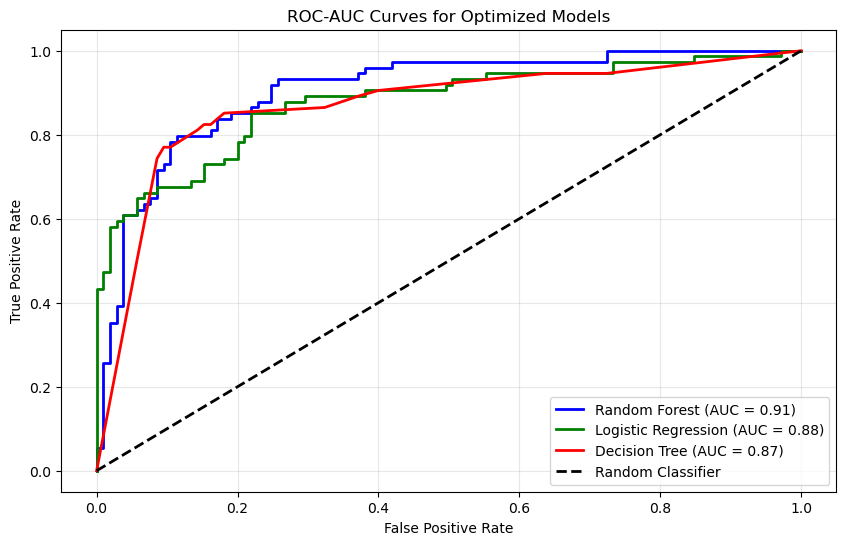

In [37]:
# ROC-AUC Curves for Best Models
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['blue', 'green', 'red']
model_names = ['Random Forest', 'Logistic Regression', 'Decision Tree']
models_list = [best_rf, best_lr, best_dt]
preds_list = [y_pred_best_rf, y_pred_best_lr, y_pred_best_dt]

for model, pred, name, color in zip(models_list, preds_list, model_names, colors):
    # Get probability predictions for ROC curve
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-AUC Curves for Optimized Models')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

Random Forest:
  Cross-validation scores: [0.82517483 0.85314685 0.81690141 0.79577465 0.84507042]
  Mean: 0.8272 (+/- 0.0204)

Logistic Regression:
  Cross-validation scores: [0.79020979 0.82517483 0.82394366 0.75352113 0.80985915]
  Mean: 0.8005 (+/- 0.0267)

Decision Tree:
  Cross-validation scores: [0.79020979 0.8041958  0.82394366 0.83098592 0.82394366]
  Mean: 0.8147 (+/- 0.0151)



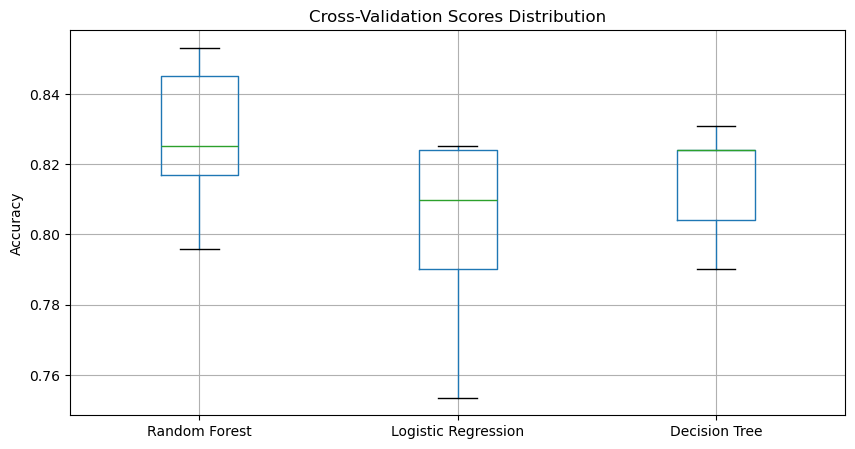

In [38]:
# Cross-Validation Scores for Best Models
from sklearn.model_selection import cross_val_score

cv_scores = {}
model_names = ['Random Forest', 'Logistic Regression', 'Decision Tree']
models_list = [best_rf, best_lr, best_dt]

for name, model in zip(model_names, models_list):
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores
    print(f"{name}:")
    print(f"  Cross-validation scores: {scores}")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

# Visualize cross-validation scores
fig, ax = plt.subplots(figsize=(10, 5))
cv_df = pd.DataFrame(cv_scores)
cv_df.boxplot(ax=ax)
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation Scores Distribution')
plt.show()

# خلاصه‌گیری و نتایج نهایی

In [39]:
# Final Summary Report
print("="*60)
print("خلاصه‌گیری پروژه تحلیل بقای تایتانیک")
print("="*60)
print("\n1. بهترین مدل (بدون بهینه‌سازی):")

# Get accuracies without optimization
rf_acc = accuracy_score(y_test, y_pred_rf) * 100
lr_acc = accuracy_score(y_test, y_pred_scaled) * 100
dt_acc = accuracy_score(y_test, tree_predictions) * 100

best_accuracy = max(rf_acc, lr_acc, dt_acc)

if best_accuracy == rf_acc:
    best_model = "Random Forest"
elif best_accuracy == lr_acc:
    best_model = "Logistic Regression"
else:
    best_model = "Decision Tree"

print(f"   - نام مدل: {best_model}")
print(f"   - دقت: {best_accuracy:.2f}%")

print("\n2. عوامل مؤثر بر بقا:")
for idx, (feature, importance) in enumerate(feature_imp.head().items(), 1):
    print(f"   {idx}. {feature}: {importance*100:.2f}%")

print("\n3. عملکرد مدل‌ها (بدون بهینه‌سازی):")
print(f"   - Random Forest: {rf_acc:.2f}%")
print(f"   - Logistic Regression: {lr_acc:.2f}%")
print(f"   - Decision Tree: {dt_acc:.2f}%")

print("\n4. عملکرد مدل‌ها (بعد از بهینه‌سازی Hyperparameter Tuning):")
print(f"   - Random Forest: {accuracy_score(y_test, y_pred_best_rf)*100:.2f}%")
print(f"   - Logistic Regression: {accuracy_score(y_test, y_pred_best_lr)*100:.2f}%")
print(f"   - Decision Tree: {accuracy_score(y_test, y_pred_best_dt)*100:.2f}%")

print("\n" + "="*60)
print("✓ THE END")
print("="*60)

خلاصه‌گیری پروژه تحلیل بقای تایتانیک

1. بهترین مدل (بدون بهینه‌سازی):
   - نام مدل: Random Forest
   - دقت: 82.12%

2. عوامل مؤثر بر بقا:
   1. Sex: 26.84%
   2. Fare: 26.84%
   3. Age: 24.88%
   4. Pclass: 7.25%
   5. FamilySize: 4.84%

3. عملکرد مدل‌ها (بدون بهینه‌سازی):
   - Random Forest: 82.12%
   - Logistic Regression: 79.89%
   - Decision Tree: 79.33%

4. عملکرد مدل‌ها (بعد از بهینه‌سازی Hyperparameter Tuning):
   - Random Forest: 82.68%
   - Logistic Regression: 79.33%
   - Decision Tree: 84.36%

✓ THE END
